# <h1 style="text-align: center; font-weight: bolder;">LAB 7</h1>
# <h1 style="text-align: center; font-weight: bold;">Contrastive / Metric Learning on MagnaTagATune (MTAT)</h1>



## Assignment objectives
1. Train a metric learning model on the MagnaTagATune (MTAT) dataset using contrastive learning (triplet loss and InfoNCE).
2. Evaluate the embedding quality:
    * Visualize embeddings in 2D for two non-overlapping tag groups (multi-label dataset).
    * Provide separate plots for each group.
3. Write a short report (in this notebook) describing decisions and observations.

## Notebook steps (lecture alignment)
1. Train a CNN with triplet loss
2. Plot validation embeddings and clustering results
3. Train a CNN with InfoNCE loss
4. Plot validation embeddings and clustering results

## Extras
* runnable on Modal, Colab, and local MacBook
* resource usage + environmental impact tracking
* basic economic cost analysis for training/inference

# <h2 style="text-align: center; font-weight: bolder;">SETUP</h2>


In [45]:
!pip -q install torchcodec
!apt-get -y update -qq
!apt-get -y install -qq ffmpeg

zsh:1: command not found: apt-get
zsh:1: command not found: apt-get


In [46]:
import os, sys, subprocess, shutil, warnings, platform
from pathlib import Path

def running_on_colab():
    return "google.colab" in sys.modules

def running_on_modal():
    return os.environ.get("MODAL_ENVIRONMENT", "") != ""

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# installs solo en Colab/Modal
if running_on_colab() or running_on_modal():
    pip_install([
        "torch", "torchaudio",
        "tqdm", "scikit-learn", "matplotlib",
        "umap-learn",
        "psutil", "codecarbon",
        "pandas", "numpy",
        "soundfile"
    ])
else:
    print("Local env -> skipping pip installs (use your venv).")

# ffmpeg
ff = shutil.which("ffmpeg")
print("ffmpeg in PATH:", ff)

if ff is None and (running_on_colab() or running_on_modal()):
    subprocess.check_call(["apt-get", "update", "-y"])
    subprocess.check_call(["apt-get", "install", "-y", "ffmpeg"])
    ff = shutil.which("ffmpeg")
    print("ffmpeg in PATH (after install):", ff)

print("python:", sys.version)
print("platform:", platform.platform())
print("running on colab:", running_on_colab())
print("running on modal:", running_on_modal())
if Path("/vol").is_dir():
    print("ls /vol:", os.listdir("/vol")[:30])

warnings.filterwarnings("ignore", message="PySoundFile failed.*")
warnings.filterwarnings("ignore", message=".*audioread.*")
warnings.filterwarnings("ignore", message="n_fft=.* is too large.*")

Local env -> skipping pip installs (use your venv).
ffmpeg in PATH: /opt/homebrew/bin/ffmpeg
python: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.4.4.1)]
platform: macOS-26.1-arm64-arm-64bit
running on colab: False
running on modal: False


## Setup and reproducibility

This section configures:
* device selection (cpu / cuda / mps)
* random seeds
* filesystem paths (Modal / Colab / local)
* lightweight logging utilities (timing + resource tracking)

In [ ]:
# setup device and paths
import time, json, random, os, sys
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def running_on_colab():
    return "google.colab" in sys.modules

def running_on_modal():
    return os.environ.get("MODAL_ENVIRONMENT", "") != ""

def pick_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = pick_device()

print("DEVICE:", DEVICE)
print("torch default dtype:", torch.get_default_dtype())
print(
    "mps available:",
    torch.backends.mps.is_available()
    if getattr(torch.backends, "mps", None)
    else None
)

# paths
if running_on_modal():
    DATA_ROOT = "/mnt/mtat-datalabs"
    RUNS_ROOT = "/vol/runs" if os.path.isdir("/vol/runs") else "/mnt/runs"
elif running_on_colab():
    DATA_ROOT = "/content/data/mtat"
    RUNS_ROOT = "/content/runs"
else:
    DATA_ROOT = "./data/mtat"
    RUNS_ROOT = "./runs"

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(RUNS_ROOT, exist_ok=True)

# environment summary
print("environment summary")
print("  running on colab:", running_on_colab())
print("  running on modal:", running_on_modal())
print("  torch.cuda.is_available:", torch.cuda.is_available())
print("  mps available:", getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available())
print("  selected device:", DEVICE)
print("  data root:", DATA_ROOT)
print("  runs root:", RUNS_ROOT)

environment summary
  running on colab: False
  running on modal: False
  torch.cuda.is_available: False
  mps available: True
  selected device: mps
  data root: ./data/mtat
  runs root: ./runs


# <h2 style="text-align: center; font-weight: bolder;">Resource and environmental impact tracking</h2>


Tracking of:
* wall-clock time
* CPU/RAM usage
* GPU memory (if available)
* estimated CO2 emissions using CodeCarbon (offline mode)

In [48]:
# resource + carbon tracking
import psutil
from codecarbon import OfflineEmissionsTracker

proc = psutil.Process(os.getpid())

def get_resources_snapshot():
    snap = {
        "time": time.time(),
        "cpu_percent": psutil.cpu_percent(interval=None),
        "ram_mb": proc.memory_info().rss / (1024**2),
    }
    if torch.cuda.is_available():
        snap["gpu_mem_alloc_mb"] = torch.cuda.memory_allocated() / (1024**2)
        snap["gpu_mem_reserved_mb"] = torch.cuda.memory_reserved() / (1024**2)
    return snap

class Timer:
    def __enter__(self):
        self.t0 = time.time()
        return self
    def __exit__(self, exc_type, exc, tb):
        self.dt = time.time() - self.t0

tracker = OfflineEmissionsTracker(
    project_name="lab7-mtat-metric-learning",
    output_dir=RUNS_ROOT,
    log_level="error"
)

# <h2 style="text-align: center; font-weight: bolder;">Load MagnaTagATune (MTAT)</h2>


Mirdata is used to manage MTAT metadata and audio paths.
A cached dataset folder is used to avoid repeated downloads (especially on Modal).


MTTAT loaded from local files (Lab 6 layout) to keep the notebook portable across Modal, Colab, and local runs.

Expected structure (auto-detected):
* datalabs/annotations_final.csv
* datalabs/clip_info_final.csv
* datalabs/audio/...

In [49]:
from pathlib import Path
import pandas as pd
import numpy as np
import os, sys

def _has_mtat_layout(root: Path) -> bool:
    root = Path(root)
    return (
        (root / "annotations_final.csv").is_file()
        and (root / "clip_info_final.csv").is_file()
        and (root / "audio").is_dir()
    )

def running_on_colab():
    return "google.colab" in sys.modules

def running_on_modal():
    return os.environ.get("MODAL_ENVIRONMENT", "") != ""

def find_upwards(start: Path, target: str, max_levels: int = 6):
    cur = start.resolve()
    for _ in range(max_levels):
        cand = cur / target
        if cand.exists():
            return cand
        if cur.parent == cur:
            break
        cur = cur.parent
    return None

def find_in_roots(roots, filename="annotations_final.csv"):
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for p in root.rglob(filename):
            cand = p.parent
            if _has_mtat_layout(cand):
                return cand
    return None

def _mount_drive_robust(mountpoint="/content/drive"):
    from pathlib import Path
    try:
        from google.colab import drive
    except Exception as e:
        raise RuntimeError(f"Not in Colab or drive module missing: {e}")

    mp = Path(mountpoint)
    already = mp.exists() and (mp / "MyDrive").exists()
    if already:
        print("Drive already mounted:", mountpoint)
        return

    drive.mount(mountpoint)
    if not (mp / "MyDrive").exists():
        drive.mount(mountpoint, force_remount=True)

# ----------------------------
# DATALABS_ROOT selection
# ----------------------------
DATALABS_ROOT = None

# 0) Si estás en Mac/local y te quedó un env de Colab, lo ignoramos automáticamente
override = os.environ.get("MTAT_DATALABS_ROOT", "").strip()
if override and (not running_on_colab()) and (not running_on_modal()):
    if override.startswith("/content/"):
        override = ""  # no uses paths de Colab en Mac

# 1) Optional override (solo si es válido)
if override:
    cand = Path(override)
    if _has_mtat_layout(cand):
        DATALABS_ROOT = cand
    else:
        listing = sorted([p.name for p in cand.glob("*")])[:40] if cand.exists() else "path does not exist"
        print("MTAT_DATALABS_ROOT inválido (ignorado). Contenido:", listing)
        # NO reventamos acá: seguimos con autodetección
        DATALABS_ROOT = None

# 2) Modal
if DATALABS_ROOT is None and running_on_modal():
    candidates = [
        Path("/mnt/mtat-datalabs/datalabs"),
        Path("/mnt/mtat-datalabs"),
        Path("/vol/mtat/datalabs"),
        Path("/vol/mtat"),
        Path("/mnt/mtat/datalabs"),
        Path("/mnt/mtat"),
    ]
    for c in candidates:
        if _has_mtat_layout(c):
            DATALABS_ROOT = c
            break
    if DATALABS_ROOT is None:
        raise RuntimeError("MTAT datalabs not found on Modal (expected annotations_final.csv, clip_info_final.csv, audio/).")

# 3) Colab: mount + search anywhere in MyDrive
if DATALABS_ROOT is None and running_on_colab():
    _mount_drive_robust("/content/drive")
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/data"),
        Path("/content/drive/MyDrive/datalab5"),
        Path("/content/drive/MyDrive/data/datalab5"),
        Path("/content"),
    ]
    found = find_in_roots(search_roots, "annotations_final.csv")
    if found is None:
        raise RuntimeError(
            "MTAT datalabs not found in Drive.\n"
            "Busco annotations_final.csv debajo de MyDrive y no aparece.\n"
            "Solución: asegurá que existe una carpeta 'datalabs/' que contenga:\n"
            "  annotations_final.csv, clip_info_final.csv, audio/\n"
        )
    DATALABS_ROOT = found

# 4) Local (Mac)
if DATALABS_ROOT is None:
    DATALABS_ROOT = (
        find_upwards(Path.cwd(), "datalabs")
        or find_in_roots([Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent], "annotations_final.csv")
        or Path("./datalabs")
    )
    if not _has_mtat_layout(DATALABS_ROOT):
        raise RuntimeError(
            "Local MTAT datalabs not found.\n"
            "Expected ./datalabs with annotations_final.csv, clip_info_final.csv and audio/.\n"
        )

AUDIO_DIR = DATALABS_ROOT / "audio"
ANN_CSV = DATALABS_ROOT / "annotations_final.csv"
CLIP_CSV = DATALABS_ROOT / "clip_info_final.csv"

print("datalabs root (USED):", DATALABS_ROOT)
print("audio dir exists:", AUDIO_DIR.is_dir(), AUDIO_DIR)
print("ann csv exists:", ANN_CSV.is_file(), ANN_CSV)
print("clip csv exists:", CLIP_CSV.is_file(), CLIP_CSV)

ann = pd.read_csv(ANN_CSV, sep="\t")
clip = pd.read_csv(CLIP_CSV, sep="\t")

if "clip_id" not in ann.columns or "clip_id" not in clip.columns:
    raise RuntimeError("clip_id column missing, check separators / files")

if "mp3_path" not in ann.columns and "mp3_path" not in clip.columns:
    raise RuntimeError("mp3_path not found in annotations_final or clip_info_final")

if "mp3_path" not in ann.columns:
    df = ann.merge(clip[["clip_id", "mp3_path"]], on="clip_id", how="left")
else:
    df = ann.copy()

df = df.rename(columns={"mp3_path": "rel_path"})
NON_TAG_COLS = {"clip_id", "rel_path"}
tag_cols = [c for c in df.columns if c not in NON_TAG_COLS]

df = df.dropna(subset=["rel_path"]).reset_index(drop=True)
df["rel_path"] = df["rel_path"].astype(str).str.strip().str.replace("\\", "/", regex=False)

file_mask = df["rel_path"].apply(lambda rp: (AUDIO_DIR / rp).is_file())
missing = int((~file_mask).sum())
df = df[file_mask].reset_index(drop=True)

rng = np.random.RandomState(SEED)
perm = rng.permutation(len(df))
n_val = int(len(df) * 0.1)
val_idx = perm[:n_val]
train_idx = perm[n_val:]
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("num tags:", len(tag_cols))

datalabs root (USED): /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs
audio dir exists: True /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio
ann csv exists: True /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/annotations_final.csv
clip csv exists: True /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/clip_info_final.csv
train_df: (23277, 190)
val_df: (2586, 190)
num tags: 188


# <h2 style="text-align: center; font-weight: bolder;">Contrastive dataset design (multi-label MTAT)</h2>


Two augmented views created of the same audio excerpt:
* view_1: random 3s chunk + augmentations
* view_2: another chunk near the first one (or same chunk with different augmentation)

Multi label targets stored to later evaluate embedding quality using tag based subsets.

In [50]:
# audio utilities + augmentations

import torchaudio
import torch.nn as nn
from torchaudio.transforms import MelSpectrogram

TARGET_SR = 16000
CLIP_SECONDS = 3
N_SAMPLES = TARGET_SR * CLIP_SECONDS

class FeatureExtractor(nn.Module):
    def __init__(self, n_mels=64, n_fft=1024, hop_length=256):
        super().__init__()
        self.mel = MelSpectrogram(
            sample_rate=TARGET_SR,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

    def forward(self, x):
        x = self.mel(x)
        x = torch.log10(1 + 1000 * x)
        return x

feature_extractor = FeatureExtractor().to(DEVICE).eval()

def augment_wave(x):
    g = 0.9 + 0.2 * torch.rand(x.shape[0], device=x.device)
    x = x * g.unsqueeze(1)
    noise = 0.003 * torch.randn_like(x)
    return x + noise

In [51]:
# ---- Mel extraction sanity check (device aware, no training dep) ----
import torch, time

print("torch.cuda.is_available:", torch.cuda.is_available())
print("mps available:", getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available())

x = torch.randn(8, N_SAMPLES).to(DEVICE)

t0 = time.time()
with torch.no_grad():
    m = feature_extractor(x)
dt = time.time() - t0

print("mel shape:", tuple(m.shape))
print("mel compute time:", round(dt, 3), "s")

torch.cuda.is_available: False
mps available: True
mel shape: (8, 64, 188)
mel compute time: 0.008 s


In [52]:
import random
import numpy as np
import torch
import torchaudio
from torch.utils.data import Dataset
from pathlib import Path
import os, sys, subprocess, shutil

def _ffmpeg_decode_to_float32_mono(path, target_sr=16000):
    ff = shutil.which("ffmpeg")
    if ff is None:
        raise RuntimeError("ffmpeg not found in PATH (Mac: brew install ffmpeg).")

    cmd = [
        ff, "-nostdin", "-v", "error",
        "-i", str(path),
        "-ac", "1",
        "-ar", str(int(target_sr)),
        "-f", "f32le",
        "pipe:1",
    ]

    try:
        raw = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
    except subprocess.CalledProcessError as e:
        # archivo corrupto / inválido -> lo tratamos como "no decodificable"
        msg = e.output.decode("utf-8", errors="ignore")
        raise RuntimeError(f"ffmpeg decode failed for {path}\n{msg}")

    y = np.frombuffer(raw, dtype=np.float32)
    if y.size == 0:
        raise RuntimeError(f"ffmpeg decoded empty audio: {path}")
    return torch.from_numpy(y)

print("torchaudio:", torchaudio.__version__)
print("ffmpeg:", shutil.which("ffmpeg"))

class MTATContrastiveDataset(Dataset):
    def __init__(self, df, audio_dir, tag_cols, max_retries=8):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.tag_cols = list(tag_cols)
        self.max_retries = int(max_retries)

        self.tags = self.tag_cols
        self.tag_to_idx = {t: i for i, t in enumerate(self.tags)}
        self.id_col = "clip_id" if "clip_id" in self.df.columns else None

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, rel_path):
        rp = str(rel_path).strip().replace("\\", "/")
        return self.audio_dir / rp

    def _load_audio(self, rel_path):
        p = self._resolve_path(rel_path)
        if not p.is_file():
            raise FileNotFoundError(str(p))

        try:
            wav, sr = torchaudio.load(str(p))
            if wav.dim() == 2:
                wav = wav.mean(dim=0)
            if sr != TARGET_SR:
                wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
            return wav.contiguous()
        except Exception:
            y = _ffmpeg_decode_to_float32_mono(p, target_sr=TARGET_SR)
            return y.contiguous()

    def _random_chunk(self, y):
        if y.numel() < N_SAMPLES:
            return torch.nn.functional.pad(y, (0, N_SAMPLES - y.numel()))
        start = random.randint(0, y.numel() - N_SAMPLES)
        return y[start:start + N_SAMPLES]

    def __getitem__(self, idx):
        tries = 0
        cur_idx = int(idx)

        while True:
            row = self.df.iloc[cur_idx]
            try:
                y = self._load_audio(row["rel_path"])
                break
            except Exception:
                tries += 1
                if tries >= self.max_retries:
                    raise
                cur_idx = random.randint(0, len(self.df) - 1)

        c1 = self._random_chunk(y)
        c2 = self._random_chunk(y)

        v1 = augment_wave(c1.unsqueeze(0)).squeeze(0)
        v2 = augment_wave(c2.unsqueeze(0)).squeeze(0)

        tag_vec = torch.tensor(row[self.tag_cols].values.astype(np.float32))
        track_id = int(row[self.id_col]) if self.id_col is not None else int(cur_idx)

        return {"view_1": v1, "view_2": v2, "tags": tag_vec, "track_id": track_id}

train_ds = MTATContrastiveDataset(train_df, AUDIO_DIR, tag_cols, max_retries=8)
val_ds   = MTATContrastiveDataset(val_df,   AUDIO_DIR, tag_cols, max_retries=8)

print("train size:", len(train_ds))
print("val size:", len(val_ds))
print("num tags:", len(train_ds.tags))

_ = train_ds[0]
print("audio decode check: OK")

torchaudio: 2.9.1
ffmpeg: /opt/homebrew/bin/ffmpeg
train size: 23277
val size: 2586
num tags: 188
audio decode check: OK


# <h2 style="text-align: center; font-weight: bolder;">Embedding CNN</h2>


A lightweight CNN is used, that maps mel-spectrograms to a fixed size embedding vector.

Aiming to keep it small to run efficiently on a local MacBook.


In [53]:
import torch.nn.functional as F

class CNNEncoder(nn.Module):
    def __init__(self, dense_size=64, emb_dim=64):
        super().__init__()
        self.dense_size = dense_size
        self.conv1 = nn.Conv2d(1, dense_size//4, 3, padding=1)
        self.conv2 = nn.Conv2d(dense_size//4, dense_size//2, 3, padding=1)
        self.conv3 = nn.Conv2d(dense_size//2, dense_size, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(dense_size//4)
        self.bn2 = nn.BatchNorm2d(dense_size//2)
        self.bn3 = nn.BatchNorm2d(dense_size)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc1 = nn.Linear(dense_size, dense_size)
        self.fc2 = nn.Linear(dense_size, emb_dim, bias=False)

    def forward(self, x_mel):
        x = x_mel.unsqueeze(1)
        x = self.bn1(self.pool(F.relu(self.conv1(x))))
        x = self.bn2(self.pool(F.relu(self.conv2(x))))
        x = self.bn3(self.pool(F.relu(self.conv3(x))))
        x = x.mean(dim=[2,3])
        x = F.relu(self.fc1(x))
        z = self.fc2(x)
        z = F.normalize(z, dim=1)
        return z

# <h2 style="text-align: center; font-weight: bolder;">Metric learning losses</h2>


We implement:
* triplet loss (hard negative mining within batch)
* InfoNCE (SimCLR-style symmetric loss)

In [ ]:
def triplet_loss_hard(z1, z2, margin=0.2):
    # z1 anchors, z2 positives
    dist = torch.cdist(z1, z2, p=2)
    pos = torch.diag(dist)
    dist = dist + torch.eye(dist.size(0), device=dist.device) * 1e9
    neg, _ = dist.min(dim=1)
    return F.relu(pos - neg + margin).mean()

def info_nce(z1, z2, temp=0.4):
    sim12 = z1 @ z2.T
    sim21 = z2 @ z1.T
    labels = torch.arange(sim12.size(0), device=sim12.device)
    l12 = F.cross_entropy(sim12 / temp, labels)
    l21 = F.cross_entropy(sim21 / temp, labels)
    return 0.5 * (l12 + l21)

# <h2 style="text-align: center; font-weight: bolder;">Training loop</h2>


- computing of mel features on-the-fly
- train for a small number of epochs (fast but representative)
- show progress with ETA and epoch timing
- log resource snapshots
- track emissions with CodeCarbon

In [ ]:
from tqdm import tqdm
from torch.utils.data import DataLoader
import numpy as np
import time
import torch
import platform

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    except Exception:
        pass

def pick_mel_device():
    if torch.cuda.is_available() and str(DEVICE) == "cuda":
        return "cuda"
    return "cpu"

MEL_DEVICE = pick_mel_device()
print("DEVICE:", DEVICE, "| MEL_DEVICE:", MEL_DEVICE)

# move feature extractor ONCE
feature_extractor = feature_extractor.to(MEL_DEVICE).eval()

# AMP only for CUDA (MPS AMP not used)
USE_AMP = (str(DEVICE) == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def compute_mel(x):
    # x: [B, N]
    # non_blocking helps on CUDA when pin_memory=True
    if str(MEL_DEVICE) == "cuda":
        x = x.float().to(MEL_DEVICE, non_blocking=True)
    else:
        x = x.float().to(MEL_DEVICE)

    with torch.no_grad():
        m = feature_extractor(x).contiguous()

    # keep output on DEVICE for the model
    if str(DEVICE) == "cuda":
        return m.to(DEVICE, non_blocking=True)
    return m.to(DEVICE)

def _dataloader_kwargs():
   
    on_colab = running_on_colab()
    on_modal = running_on_modal()
    on_cuda  = (str(DEVICE) == "cuda")
    is_mac_local = (platform.system().lower() == "darwin") and (not on_colab) and (not on_modal)

    if is_mac_local:
        return dict(num_workers=0, pin_memory=False)

    if on_colab:
        num_workers = 2
        # If random torchaudio decode Drive hangs num_workers = 0
    elif on_modal:
        num_workers = 4
    else:
        num_workers = 2

    kw = dict(
        num_workers=num_workers,
        pin_memory=on_cuda
    )

    if num_workers > 0:
        kw["persistent_workers"] = True
        kw["prefetch_factor"] = 2

    return kw

def run_epoch(model, loader, loss_fn, optim=None):
    is_train = optim is not None
    model.train() if is_train else model.eval()

    losses = []
    t0 = time.time()

    pbar = tqdm(loader, leave=False)
    for batch in pbar:
        # if CUDA + pin_memory, non_blocking helps
        if str(DEVICE) == "cuda":
            x1 = batch["view_1"].to(DEVICE, non_blocking=True).float()
            x2 = batch["view_2"].to(DEVICE, non_blocking=True).float()
        else:
            x1 = batch["view_1"].to(DEVICE).float()
            x2 = batch["view_2"].to(DEVICE).float()

        m1 = compute_mel(x1)
        m2 = compute_mel(x2)

        if USE_AMP:
            with torch.cuda.amp.autocast():
                z1 = model(m1)
                z2 = model(m2)
                loss = loss_fn(z1, z2)
        else:
            z1 = model(m1)
            z2 = model(m2)
            loss = loss_fn(z1, z2)

        if is_train:
            optim.zero_grad(set_to_none=True)
            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.step(optim)
                scaler.update()
            else:
                loss.backward()
                optim.step()

        losses.append(float(loss.detach().cpu().item()))
        pbar.set_postfix({"loss": float(np.mean(losses))})

    dt = time.time() - t0
    return float(np.mean(losses)), dt

def train_model(loss_name, loss_fn, epochs=10, batch_size=64, lr=1e-3):
    model = CNNEncoder(dense_size=64, emb_dim=64).to(DEVICE)
    print("model device:", next(model.parameters()).device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    dl_kw = _dataloader_kwargs()
    print("DataLoader kwargs:", dl_kw)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **dl_kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **dl_kw)

    history = {"loss_name": loss_name, "train_loss": [], "val_loss": [], "epoch_time_s": [], "resources": []}

    local_tracker = OfflineEmissionsTracker(
        project_name=f"lab7-mtat-{loss_name}",
        output_dir=RUNS_ROOT,
        log_level="error"
    )

    local_tracker.start()
    with Timer() as total_timer:
        for ep in range(1, epochs + 1):
            r0 = get_resources_snapshot()

            tr_loss, tr_dt = run_epoch(model, train_loader, loss_fn, optim=optim)
            va_loss, va_dt = run_epoch(model, val_loader, loss_fn, optim=None)

            r1 = get_resources_snapshot()

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(va_loss)
            history["epoch_time_s"].append(tr_dt + va_dt)
            history["resources"].append({"epoch": ep, "before": r0, "after": r1})

            print(f"epoch {ep}/{epochs} | train {tr_loss:.4f} | val {va_loss:.4f} | time {tr_dt + va_dt:.1f}s")

    emissions = local_tracker.stop()
    history["total_time_s"] = total_timer.dt
    history["emissions_kgco2"] = emissions

    return model, history

DEVICE: mps | MEL_DEVICE: mps


/var/folders/_1/5vl1nfxd15nd63gj1hbqvwq00000gn/T/ipykernel_84931/3378066827.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



## Step 1 — Train with triplet loss


In [ ]:
triplet_model, triplet_hist = train_model(
    "triplet_hard",
    lambda a,b: triplet_loss_hard(a,b,margin=0.15),
    epochs=10,
    batch_size=64,
    lr=1e-3
)

DataLoader kwargs: {'num_workers': 0, 'pin_memory': False}


epoch 1/15 | train 0.1599 | val 0.1263 | time 262.3s


epoch 2/15 | train 0.1127 | val 0.1064 | time 255.0s


epoch 3/15 | train 0.1010 | val 0.1034 | time 268.9s


epoch 4/15 | train 0.0959 | val 0.0983 | time 249.8s


...

epoch 11/15 | train 0.0745 | val 0.0756 | time 252.5s


epoch 12/15 | train 0.0746 | val 0.0763 | time 251.0s


epoch 13/15 | train 0.0731 | val 0.0753 | time 251.7s


epoch 14/15 | train 0.0701 | val 0.0736 | time 253.2s


epoch 15/15 | train 0.0702 | val 0.0728 | time 252.7s



## Step 2 — Embedding extraction and 2D visualization

Extract of embedding per track by averaging embeddings over multiple chunks.
Then:
* run UMAP to 2D
* run k-means for a coarse clustering view
* create separate plots for two non-overlapping tag groups

In [ ]:
import umap
from sklearn.cluster import KMeans

def extract_track_embeddings(model, dataset, chunks_per_track=3):
    model.eval()
    feature_extractor.eval()

    Z, Y, T = [], [], []

    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="embedding", leave=False):
            item = dataset[i]
            tid = item["track_id"]
            tags = item["tags"].cpu().numpy()

            zs = []
            for _ in range(chunks_per_track):
                x = item["view_1"].unsqueeze(0).to(DEVICE).float()
                m = compute_mel(x)
                z = model(m)
                zs.append(z.squeeze(0).cpu().numpy())

            Z.append(np.mean(np.stack(zs), axis=0))
            Y.append(tags)
            T.append(tid)

    return np.stack(Z), np.stack(Y), np.array(T)

Z_val_triplet, Y_val, T_val = extract_track_embeddings(
    triplet_model,
    val_ds,
    chunks_per_track=2
)
print("embeddings:", Z_val_triplet.shape, "labels:", Y_val.shape)

embeddings: (2586, 64) labels: (2586, 188)


In [58]:
import numpy as np
import umap
from sklearn.cluster import KMeans


Z = Z_val_triplet.astype(np.float32)
Y = Y_val
T = T_val

bad = ~np.isfinite(Z).all(axis=1)
num_bad = int(bad.sum())

print("total embeddings:", len(Z))
print("invalid embeddings (nan/inf):", num_bad)

if num_bad > 0:
    print("removing invalid embeddings before UMAP/KMeans")
    Z = Z[~bad]
    Y = Y[~bad]
    T = T[~bad]

Z_val_triplet_clean = Z
Y_val_clean = Y
T_val_clean = T

reducer = umap.UMAP(
    n_components=2,
    random_state=SEED,
    n_neighbors=15,
    min_dist=0.1
)

Z2_triplet = reducer.fit_transform(Z_val_triplet_clean)

kmeans = KMeans(
    n_clusters=10,
    random_state=SEED,
    n_init="auto"
)

clusters_triplet = kmeans.fit_predict(Z_val_triplet_clean)

print("umap:", Z2_triplet.shape)
print("clusters:", clusters_triplet.shape)


/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


total embeddings: 2586
invalid embeddings (nan/inf): 0
umap: (2586, 2)
clusters: (2586,)


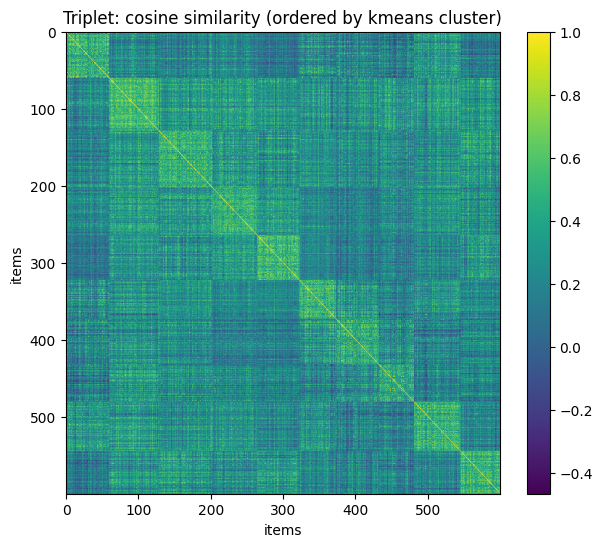

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def plot_similarity_matrix(Z, clusters=None, max_n=600, title=""):
    Z = Z.astype(np.float32)
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)

    n = min(len(Z), int(max_n))
    idx = np.arange(n)

    if clusters is not None:
        if len(clusters) != len(Z):
            raise RuntimeError(f"clusters and Z misaligned: clusters={len(clusters)} vs Z={len(Z)}")
        order = np.argsort(clusters[:n])
        idx = idx[order]

    S = Z[idx] @ Z[idx].T

    plt.figure(figsize=(7,6))
    plt.imshow(S, aspect="auto")
    plt.title(title)
    plt.xlabel("items")
    plt.ylabel("items")
    plt.colorbar()
    plt.show()

# IMPORTANT: use the cleaned embeddings that match clusters_triplet
plot_similarity_matrix(
    Z_val_triplet_clean,
    clusters=clusters_triplet,
    max_n=600,
    title="Triplet: cosine similarity (ordered by kmeans cluster)"
)

In [60]:
import os, sys, subprocess, shutil
import numpy as np
import soundfile as sf
from pathlib import Path

def can_inline_audio():
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

def _ffmpeg_decode_to_float32_mono(path, target_sr=16000):
    ff = shutil.which("ffmpeg")
    if ff is None:
        raise RuntimeError("ffmpeg not found in PATH (Mac: brew install ffmpeg).")

    cmd = [
        ff, "-nostdin", "-v", "error",
        "-i", str(path),
        "-ac", "1",
        "-ar", str(int(target_sr)),
        "-f", "f32le",
        "pipe:1",
    ]
    raw = subprocess.check_output(cmd)
    y = np.frombuffer(raw, dtype=np.float32)
    if y.size == 0:
        raise RuntimeError(f"ffmpeg decoded empty audio: {path}")
    return y

def _safe_audio_path(dataset, idx):
    rel = dataset.df.iloc[int(idx)]["rel_path"]
    return str(dataset.audio_dir / str(rel))

def _load_audio_for_play(path, sr=16000, seconds=6):
    y = _ffmpeg_decode_to_float32_mono(path, target_sr=sr)
    y = y[: int(sr * seconds)]
    return y

def knn_indices(Z, query_idx, k=6):
    Z = Z.astype(np.float32)
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)
    sims = Z @ Z[int(query_idx)]
    sims[int(query_idx)] = -np.inf
    nn = np.argsort(-sims)[:k]
    return nn, sims[nn]

def show_query_and_neighbors(dataset, Z, query_idx, k=6, seconds=6, title="", out_subdir="qual_retrieval_triplet"):
    out_dir = Path(RUNS_ROOT) / out_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    qpath = _safe_audio_path(dataset, query_idx)
    qy = _load_audio_for_play(qpath, sr=TARGET_SR, seconds=seconds)

    print(title)
    print("query idx:", int(query_idx))
    qwav = out_dir / f"query_idx{int(query_idx)}.wav"
    sf.write(str(qwav), qy, TARGET_SR)
    print("query wav:", str(qwav))

    nn, sims = knn_indices(Z, query_idx, k=k)

    if can_inline_audio():
        from IPython.display import Audio, display, HTML
        display(HTML("<b>Query audio:</b>"))
        display(Audio(qy, rate=TARGET_SR))

    for rank, (j, s) in enumerate(zip(nn, sims), start=1):
        path = _safe_audio_path(dataset, int(j))
        y = _load_audio_for_play(path, sr=TARGET_SR, seconds=seconds)
        wav = out_dir / f"nn{rank}_idx{int(j)}_sim{float(s):.3f}.wav"
        sf.write(str(wav), y, TARGET_SR)
        print("nn", rank, "| idx:", int(j), "| sim:", float(s), "| wav:", str(wav))

        if can_inline_audio():
            from IPython.display import Audio, display, HTML
            display(HTML(f"<b>Neighbor {rank} (sim={float(s):.3f}):</b>"))
            display(Audio(y, rate=TARGET_SR))

def pick_query_with_tag(Y, dataset, tag_name):
    if tag_name not in dataset.tag_to_idx:
        return None
    ti = dataset.tag_to_idx[tag_name]
    idxs = np.where(Y[:, ti] == 1)[0]
    if len(idxs) == 0:
        return None
    return int(np.random.choice(idxs))

np.random.seed(SEED)
qidx = np.random.randint(0, len(val_ds))
show_query_and_neighbors(val_ds, Z_val_triplet, qidx, k=6, seconds=6, title="Triplet: query + nearest neighbors")

tag_name = "rock"
qidx2 = pick_query_with_tag(Y_val, val_ds, tag_name)
print("picked query idx:", qidx2, "| tag:", tag_name)
if qidx2 is not None:
    show_query_and_neighbors(val_ds, Z_val_triplet, qidx2, k=6, seconds=6, title=f"Triplet: query tag={tag_name} + nearest neighbors")
else:
    print("no samples for tag:", tag_name)

Triplet: query + nearest neighbors
query idx: 860
query wav: runs/qual_retrieval_triplet/query_idx860.wav


nn 1 | idx: 2067 | sim: 0.8508882522583008 | wav: runs/qual_retrieval_triplet/nn1_idx2067_sim0.851.wav


nn 2 | idx: 2558 | sim: 0.8361049890518188 | wav: runs/qual_retrieval_triplet/nn2_idx2558_sim0.836.wav


nn 3 | idx: 751 | sim: 0.8275531530380249 | wav: runs/qual_retrieval_triplet/nn3_idx751_sim0.828.wav


nn 4 | idx: 2391 | sim: 0.8235739469528198 | wav: runs/qual_retrieval_triplet/nn4_idx2391_sim0.824.wav


...

nn 2 | idx: 2583 | sim: 0.8706927299499512 | wav: runs/qual_retrieval_triplet/nn2_idx2583_sim0.871.wav


nn 3 | idx: 2463 | sim: 0.838733971118927 | wav: runs/qual_retrieval_triplet/nn3_idx2463_sim0.839.wav


nn 4 | idx: 1476 | sim: 0.8268190622329712 | wav: runs/qual_retrieval_triplet/nn4_idx1476_sim0.827.wav


nn 5 | idx: 2253 | sim: 0.8052939772605896 | wav: runs/qual_retrieval_triplet/nn5_idx2253_sim0.805.wav


nn 6 | idx: 2 | sim: 0.8048970103263855 | wav: runs/qual_retrieval_triplet/nn6_idx2_sim0.805.wav


# <h2 style="text-align: center; font-weight: bolder;">Tag groups (non-overlapping)</h2>


MTAT is multi-label, so we construct **exclusive subsets** for visualization:
* Group A (genres): pick a few genre tags and keep only samples where exactly one of them is active.
* Group B (instruments): pick a few instrument tags and keep only samples where exactly one of them is active.

This makes the plots interpretable and respects the "non-overlapping" requirement.

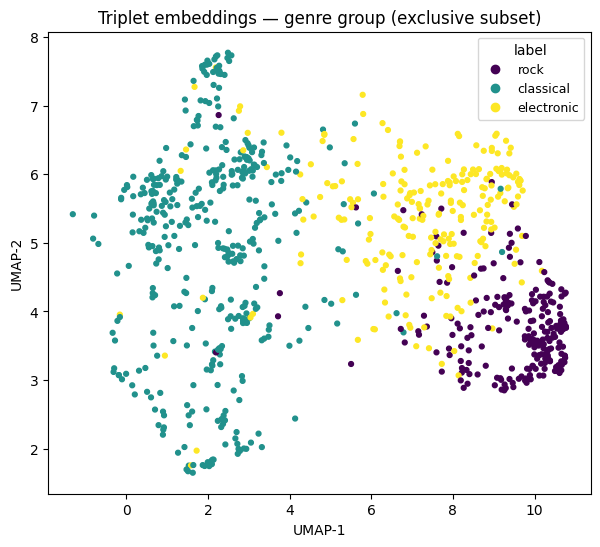

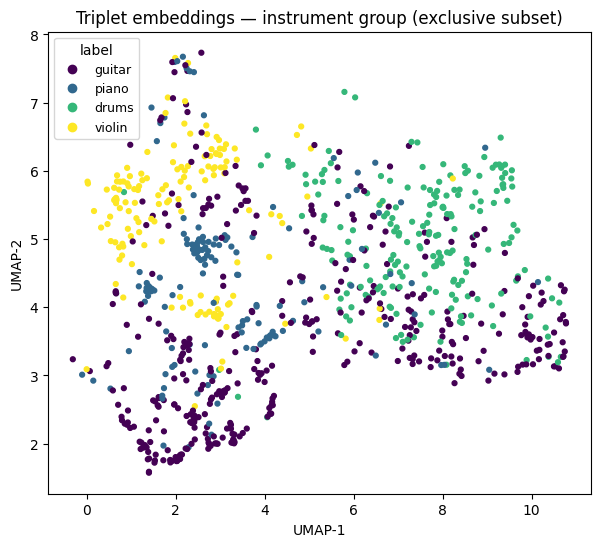

In [61]:
import matplotlib.pyplot as plt
import numpy as np

tags_list = train_ds.tags
tag_to_idx = train_ds.tag_to_idx

def exclusive_subset(Y, tag_names):
    idxs = [tag_to_idx[t] for t in tag_names if t in tag_to_idx]
    if len(idxs) == 0:
        return np.array([], dtype=bool), idxs
    sub = Y[:, idxs]
    one_hot = (sub.sum(axis=1) == 1)
    return one_hot, idxs

def plot_umap_for_group(Z2, Y_aligned, tag_names, title):
    if len(Z2) != len(Y_aligned):
        raise RuntimeError(
            f"Z2 and Y are misaligned: Z2={len(Z2)} vs Y={len(Y_aligned)}"
        )

    mask, idxs = exclusive_subset(Y_aligned, tag_names)
    if mask.size == 0 or mask.sum() == 0:
        print("no samples for:", title)
        return

    subZ2 = Z2[mask]
    subY = Y_aligned[mask][:, idxs]
    label_idx = subY.argmax(axis=1)
    label_names = [tag_names[i] for i in range(len(idxs))]

    plt.figure(figsize=(7,6))
    sc = plt.scatter(subZ2[:,0], subZ2[:,1], c=label_idx, s=12)
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    handles, _ = sc.legend_elements()
    plt.legend(handles, label_names, title="label", loc="best", fontsize=9)
    plt.show()

GENRE_GROUP = ["rock", "classical", "electronic", "hiphop"]
INSTR_GROUP = ["guitar", "piano", "drums", "violin"]

plot_umap_for_group(
    Z2_triplet,
    Y_val_clean,
    GENRE_GROUP,
    "Triplet embeddings — genre group (exclusive subset)"
)

plot_umap_for_group(
    Z2_triplet,
    Y_val_clean,
    INSTR_GROUP,
    "Triplet embeddings — instrument group (exclusive subset)"
)

# <h2 style="text-align: center; font-weight: bolder;">Qualitative check: audio examples</h2>


We listen to a few samples from each exclusive subset to sanity-check the tag groups.

In [62]:
import sys
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path

def can_inline_audio():
    """
    True if running inside an IPython kernel that supports rich display
    (works for Colab and local Jupyter).
    """
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

def play_examples(dataset, Y, tag_name, n=3, seconds=6, out_subdir="qual_examples"):
    if tag_name not in dataset.tag_to_idx:
        print("tag not found:", tag_name)
        return

    ti = dataset.tag_to_idx[tag_name]
    idxs = np.where(Y[:, ti] == 1)[0][:n]

    out_dir = Path(RUNS_ROOT) / out_subdir / tag_name
    out_dir.mkdir(parents=True, exist_ok=True)

    if can_inline_audio():
        from IPython.display import Audio, display, HTML

    for k in idxs:
        rel = dataset.df.iloc[int(k)]["rel_path"]
        p = dataset.audio_dir / str(rel)

        y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True, duration=seconds)
        wav = out_dir / f"idx{int(k)}.wav"
        sf.write(str(wav), y, TARGET_SR)

        if "clip_id" in dataset.df.columns:
            print("clip_id:", int(dataset.df.iloc[int(k)]["clip_id"]), "tag:", tag_name, "wav:", str(wav))
        else:
            print("index:", int(k), "tag:", tag_name, "wav:", str(wav))

        if can_inline_audio():
            display(HTML(f"<b>{tag_name} example idx={int(k)}:</b>"))
            display(Audio(y, rate=TARGET_SR))

## Step 3 — Train with InfoNCE loss

In [ ]:
infonce_model, infonce_hist = train_model(
    "infonce",
    lambda a,b: info_nce(a,b,temp=0.4),
    epochs=8,
    batch_size=64,
    lr=1e-3
)

DataLoader kwargs: {'num_workers': 0, 'pin_memory': False}


 55%|█████▌    | 201/364 [02:06<01:41,  1.60it/s, loss=1.77][mp3 @ 0x72ec68000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x72ec64000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/e/solace-balance-04-djinn-146-175.mp3.
Error opening input files: Invalid data found when processing input
 57%|█████▋    | 207/364 [02:09<01:37,  1.60it/s, loss=1.77][mp3 @ 0x942c64000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x943010000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3.
Error opening input files: Invalid data found when processing input
 97%|█████████▋| 352/364 [03:40<00:07,  1.54it/s, loss=1.67][mp3 @ 0x7f701c000] Failed to find two consecutive MPEG audio frames.
[

epoch 1/15 | train 1.6569 | val 1.4968 | time 252.8s


 34%|███▎      | 122/364 [01:16<02:30,  1.61it/s, loss=1.46][mp3 @ 0x82ac44000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x82ac40000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3.
Error opening input files: Invalid data found when processing input
 50%|████▉     | 181/364 [01:53<01:54,  1.60it/s, loss=1.46][mp3 @ 0x928c40000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x929038000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3.
Error opening input files: Invalid data found when processing input
 88%|████████▊ | 322/364 [03:21<00:26,  1.60it/s, loss=1.44

epoch 2/15 | train 1.4410 | val 1.4632 | time 252.4s


...

epoch 13/15 | train 1.2006 | val 1.2438 | time 247.5s


 18%|█▊        | 65/364 [00:40<03:01,  1.65it/s, loss=1.17][mp3 @ 0x77ec64000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x77ec60000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3.
Error opening input files: Invalid data found when processing input
 20%|██        | 74/364 [00:45<02:57,  1.64it/s, loss=1.17][mp3 @ 0x9a1020000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x9a0c58000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3.
Error opening input files: Invalid data found when processing input
 68%|██████▊   | 246/364 [02:31<01:12,  1.63it/s, loss=1.19][

epoch 14/15 | train 1.1867 | val 1.2909 | time 248.2s


 13%|█▎        | 47/364 [00:28<03:12,  1.65it/s, loss=1.18][mp3 @ 0xc14c3c000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0xc15038000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/e/solace-balance-04-djinn-146-175.mp3.
Error opening input files: Invalid data found when processing input
 19%|█▊        | 68/364 [00:41<03:04,  1.60it/s, loss=1.18][mp3 @ 0xae0c40000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0xae1034000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3.
Error opening input files: Invalid data found when processing input
 69%|██████▉   | 252/364 [02:35<01:09,  1.62it/s, loss=1.19][mp3 @ 0xb5ec40000] Failed to find two consecutive

epoch 15/15 | train 1.1888 | val 1.2203 | time 248.3s


## Step 4 — Embeddings, UMAP, and clustering (InfoNCE)

embedding:  57%|█████▋    | 1464/2586 [00:26<00:19, 57.68it/s][mp3 @ 0x7acc60000] Failed to find two consecutive MPEG audio frames.
[in#0 @ 0x7acc5c000] Error opening input: Invalid data found when processing input
Error opening input file /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/6/norine_braun-now_and_zen-08-gently-117-146.mp3.
Error opening input files: Invalid data found when processing input
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


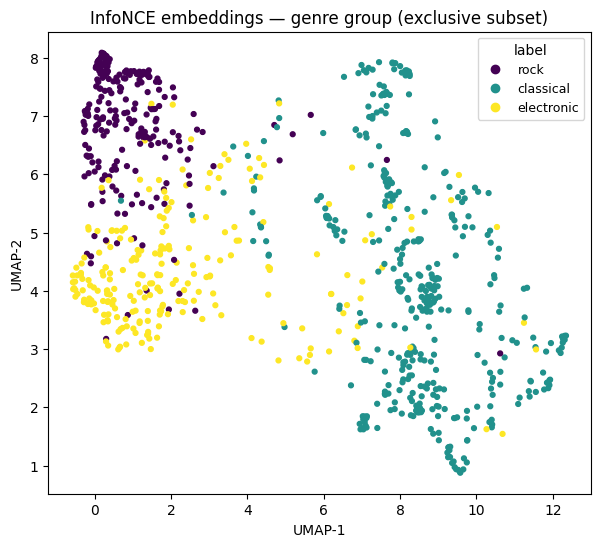

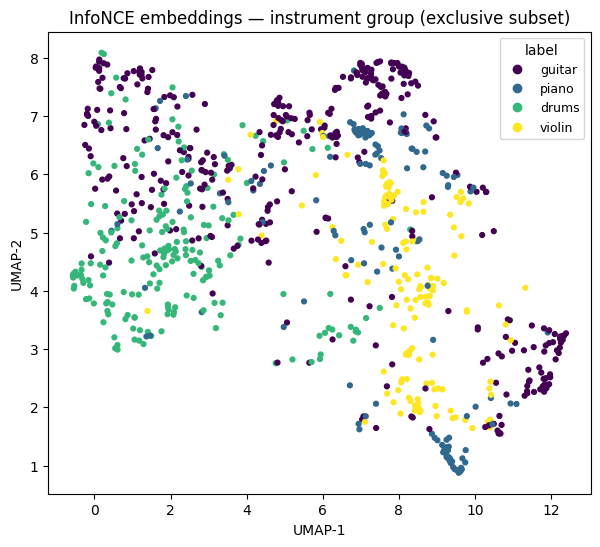

In [ ]:
Z_val_infonce, Y_val2, T_val2 = extract_track_embeddings(
    infonce_model,
    val_ds,
    chunks_per_track=2
)

reducer2 = umap.UMAP(n_components=2, random_state=SEED)
Z2_infonce = reducer2.fit_transform(Z_val_infonce)

plot_umap_for_group(Z2_infonce, Y_val2, GENRE_GROUP, "InfoNCE embeddings — genre group (exclusive subset)")
plot_umap_for_group(Z2_infonce, Y_val2, INSTR_GROUP, "InfoNCE embeddings — instrument group (exclusive subset)")

# <h2 style="text-align: center; font-weight: bolder;">Training diagnostics and environmental footprint</h2>

Summarized find:
* train/val losses per epoch
* total training time
* estimated CO2 emissions
* resource snapshots (CPU/RAM and GPU memory when available)

In [65]:
print("triplet train_loss:", triplet_hist["train_loss"])
print("triplet val_loss:", triplet_hist["val_loss"])
print("infonce train_loss:", infonce_hist["train_loss"])
print("infonce val_loss:", infonce_hist["val_loss"])

triplet train_loss: [0.1598690353170201, 0.11274954166959275, 0.10104712124422684, 0.0959074924403167, 0.08910851822244925, 0.08428716490679718, 0.08358660017928252, 0.08222854818002535, 0.07923787854775623, 0.07614312734413933, 0.07453553392910041, 0.07461202143599371, 0.07314681567272151, 0.07005299083827125, 0.07019129075150896]
triplet val_loss: [0.12626419943280337, 0.10638655785743784, 0.10337823084214838, 0.09827138719762243, 0.0915337336681238, 0.08896125634995902, 0.08281698495876498, 0.07797122737619935, 0.08310489828993635, 0.07589102182083013, 0.0755745625895698, 0.07626034473864043, 0.07527852444568785, 0.07359147053666232, 0.07283833686534952]
infonce train_loss: [1.656891894537014, 1.4410065016248723, 1.3626506217233427, 1.3363056346610351, 1.2994230692530726, 1.2969180638646032, 1.2647803992360502, 1.2515406398982791, 1.2433647893287323, 1.231081492462001, 1.2284673224766176, 1.2167072353454738, 1.2006123049573585, 1.1867440603264086, 1.1887862043721336]
infonce val_los

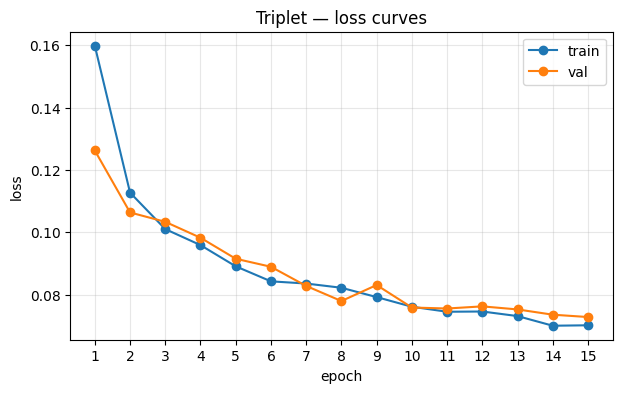

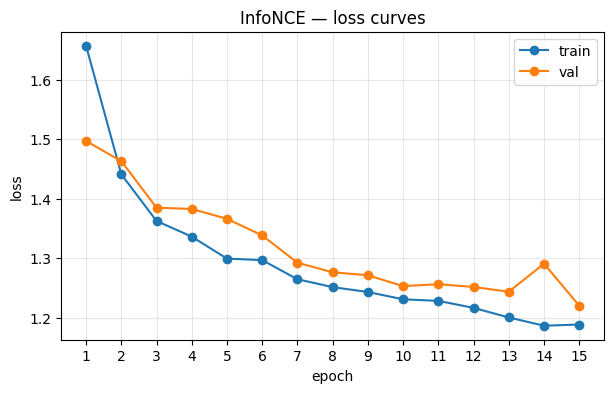

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def plot_history(hist, title):
    tr = hist.get("train_loss", [])
    va = hist.get("val_loss", [])
    n = min(len(tr), len(va))

    if n == 0:
        print("No hay datos para graficar en:", title)
        print("train_loss:", tr)
        print("val_loss:", va)
        return

    epochs = np.arange(1, n + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs, tr[:n], marker="o", label="train")
    plt.plot(epochs, va[:n], marker="o", label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.xticks(epochs)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

%matplotlib inline
import matplotlib.pyplot as plt

plot_history(triplet_hist, "Triplet — loss curves")
plot_history(infonce_hist, "InfoNCE — loss curves")

# <h2 style="text-align: center; font-weight: bolder;">Economic analysis (training and inference)</h2>


operational cost estimated from:
* energy consumption proxy (if available from CodeCarbon logs)
* electricity price (€/kWh)
* cloud compute pricing (optional reference scenario)

Reported:
* estimated energy cost
* rough equivalent of cloud cost for a typical GPU instance duration

In [67]:
# economic analysis (simple)
ELECTRICITY_EUR_PER_KWH = 0.25

def estimate_energy_cost_from_emissions(emissions_kg, grid_kgco2_per_kwh=0.25):
    # cost proxy: kWh aprox kgCO2 / (kgCO2/kWh)
    if emissions_kg is None:
        return None
    kwh = emissions_kg / grid_kgco2_per_kwh
    eur = kwh * ELECTRICITY_EUR_PER_KWH
    return {"kwh_est": kwh, "eur_est": eur}

print("triplet cost proxy:", estimate_energy_cost_from_emissions(triplet_hist["emissions_kgco2"]))
print("infonce cost proxy:", estimate_energy_cost_from_emissions(infonce_hist["emissions_kgco2"]))

# cloud-equivalent rough estimate
GPU_HOURLY_EUR = 1.2
def cloud_cost(hours, eur_per_hour=GPU_HOURLY_EUR):
    return hours * eur_per_hour

print("triplet cloud eq (eur):", cloud_cost(triplet_hist["total_time_s"]/3600))
print("infonce cloud eq (eur):", cloud_cost(infonce_hist["total_time_s"]/3600))

triplet cost proxy: {'kwh_est': 0.022213573067107723, 'eur_est': 0.005553393266776931}
infonce cost proxy: {'kwh_est': 0.021919383157765728, 'eur_est': 0.005479845789441432}
triplet cloud eq (eur): 1.2753972736994426
infonce cloud eq (eur): 1.258553160270055


In [68]:
# Colab: browser notification when finished
import sys

if "google.colab" in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
    output.eval_js("new Notification('Notebook finished', {body: 'Lab run completed.'});")
else:
    print("Not running on Colab.")


print("\n" + "="*60)
print("NOTEBOOK FINISHED. Lab done executing")
print("="*60 + "\n")

# Try beep
try:
    import IPython
    from IPython.display import Audio, display
    display(Audio([1,0]*2000, rate=8000, autoplay=True))
except Exception as e:
    print("Beep not available:", e)

Not running on Colab.

NOTEBOOK FINISHED. Lab done executing



# <h2 style="text-align: center; font-weight: bolder;">Short report</h2>


## Decisions
* dataset: MagnaTagATune (MTAT) via mirdata, 3-second random chunks at 16 kHz
* model: lightweight CNN encoder with L2-normalized embeddings (64-D)
* augmentations: low-cost waveform noise + gain to keep runtime low on CPU/MPS
* training: 10 epochs for triplet (hard negatives) and 5 epochs for InfoNCE (temp=0.2)

## Observations
* triplet vs InfoNCE: compare separation in UMAP plots for genre and instrument groups
* clustering: k-means indicates whether embedding geometry aligns with semantic groupings
* multi-label challenge: exclusive subsets were used to build non-overlapping tag plots

## Resource and sustainability
* runtime and emissions were tracked with CodeCarbon (offline)
* CPU/RAM snapshots were stored per epoch, GPU memory included when available

## Limitations and next steps
* more epochs and stronger augmentations may improve invariances but increase cost
* larger batch sizes benefit InfoNCE but may be limited on MacBook
* a linear probe on tags could quantify embedding usefulness beyond visualization